In [236]:
import pandas as pd
import numpy as np
import scipy as sp
import scipy.spatial.distance as spd
import importlib

import plotly.express as px
import matplotlib.pyplot as plt

import irina.utility_functions as uf

In [237]:
year = 2023

In [238]:
df_cs_indiv = pd.read_csv(uf.PATH+"df_country_subfield/individual_{}.csv".format(year), index_col=0)
df_cs_collab = pd.read_csv(uf.PATH+"df_country_subfield/collaborative_{}.csv".format(year), index_col=0)

In [239]:
df_cs_collab

,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3603,3604,3605,3607,3608,3609,3611,3612,3614,3616
country,,,,,,,,,,,,,,,,,,,,,
AD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AE,4.0,9.0,11.0,5.0,6.0,72.0,1.0,1.0,5.0,141.0,...,6.0,16.0,25.0,1.0,NaN,3.0,2.0,5.0,12.0,9.0
AF,5.0,4.0,1.0,NaN,2.0,6.0,NaN,NaN,3.0,15.0,...,NaN,2.0,NaN,NaN,NaN,NaN,NaN,1.0,4.0,1.0
AG,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AL,1.0,3.0,4.0,3.0,NaN,6.0,NaN,NaN,1.0,7.0,...,2.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YE,2.0,5.0,3.0,3.0,4.0,11.0,NaN,NaN,3.0,26.0,...,5.0,1.0,3.0,2.0,NaN,NaN,NaN,1.0,3.0,NaN
ZA,42.0,49.0,41.0,21.0,162.0,96.0,13.0,NaN,75.0,307.0,...,3.0,21.0,14.0,7.0,NaN,20.0,7.0,6.0,29.0,19.0


In [240]:
df_country_stats = pd.read_csv(uf.PATH+f"df_country_stats_individual_{year}.csv", index_col=0)
df_country_stats

,region,entropy,norm_entropy,total_articles,log_total_articles,gini,alpha-3
country,,,,,,,
CN,Asia,4.527790,0.818853,771534.0,13.556136,0.706139,CHN
US,Americas,4.676791,0.845800,642572.0,13.373234,0.654047,USA
ID,Asia,3.698804,0.668931,264874.0,12.487010,0.855977,IDN
IN,Asia,4.708331,0.851504,235096.0,12.367749,0.652985,IND
DE,Europe,4.778026,0.864108,132503.0,11.794361,0.628929,DEU
...,...,...,...,...,...,...,...
FM,Oceania,0.693147,0.125356,2.0,0.693147,0.000000,FSM
GQ,Africa,0.693147,0.125356,2.0,0.693147,0.000000,GNQ
AW,Americas,-0.000000,-0.000000,1.0,0.000000,0.000000,ABW


In [241]:
df_stats = (
    pd.DataFrame(index=(df_cs_indiv.index.union(df_cs_collab.index)))
    .merge(uf.df_country[["alpha-2", "alpha-3", "name", "sub-region", "region"]], left_index=True, right_on="alpha-2")
    .rename(columns={"alpha-2": "country"})
    .set_index("country")
    .assign(
        total_indiv=df_cs_indiv.sum(axis=1),
        total_collab=df_cs_collab.sum(axis=1),
        log_total_indiv=lambda df: np.log(df.total_indiv),
        log_total_collab=lambda df: np.log(df.total_collab),
        gini_indiv= df_cs_indiv.apply(uf.gini, axis=1),
        gini_collab=df_cs_collab.apply(uf.gini, axis=1),
    )
)

# Jaccard dissimilarity

$$
Jaccard(A, B) = 1 - \dfrac{|A \cap B|}{|A \cup B|}
$$

In [242]:
country = "ID"

In [243]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        df_stats.loc[c, "jaccard"] = spd.jaccard(df_cs_collab.loc[c] > 0, df_cs_indiv.loc[c] > 0)
    else:
        df_stats.loc[c, "jaccard"] = 1

In [244]:
px.scatter(df_stats, x=["log_total_collab", "log_total_indiv"], y="jaccard", hover_data=["name", "region"], title="Jaccard vs N_articles")

In [245]:
# px.scatter(df_stats, x=["gini_collab", "gini_indiv"], y="jaccard", hover_data=["name", "region"], title="Jaccard vs N_articles")

In [246]:
# _, _ = uf.plot_map_continuous(df_stats, "jaccard", range=(0, 1), title=f"Jaccard Dissimilarity (national vs international profile) {year}")

In [247]:
def jaccard_turn(a, b):
    intersect = a == b
    outer_a = a[~intersect].sum()
    outer_b = b[~intersect].sum()
    return 2 * min(outer_a, outer_b) / (a[intersect].sum() + 2 * min(outer_a, outer_b))

In [248]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        df_stats.loc[c, "jaccard_turn"] = jaccard_turn(df_cs_collab.loc[c] > 0, df_cs_indiv.loc[c] > 0)
    else:
        df_stats.loc[c, "jaccard_turn"] = 1

In [250]:
px.scatter(df_stats, x=["log_total_collab", "log_total_indiv"], y="jaccard_turn", hover_data=["name", "region"], title="Jaccard Turn vs N_articles")

In [17]:
# _, _ = uf.plot_map_continuous(df_stats, "jaccard_turn", range=(0, 1), title=f"Jaccard Turnover Dissimilarity (national vs international profile) {year}")

# Bray-Curtis



In [318]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        df_stats.loc[c, "bray_curtis"] = spd.braycurtis(df_cs_collab.loc[c] > 0, df_cs_indiv.loc[c] > 0)
    else:
        df_stats.loc[c, "bray_curtis"] = 1

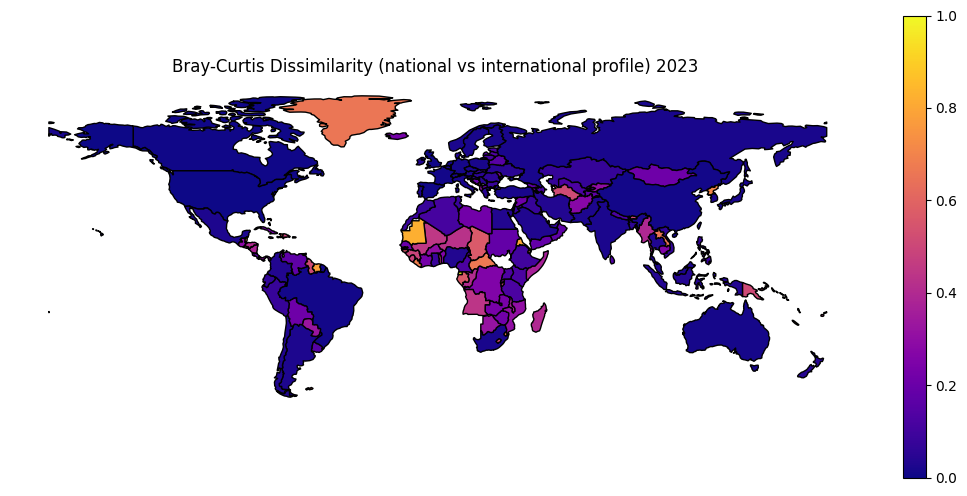

In [319]:
_, _ = uf.plot_map_continuous(df_stats, "bray_curtis", range=(0, 1), title=f"Bray-Curtis Dissimilarity (national vs international profile) {year}")

# Wasserstein-tree (probability)

In [18]:
w1_max = (
    uf.df_topics
    .sample(2)
)

In [19]:
# year = 2023
# df_cs_indiv = pd.read_csv(uf.PATH+"df_country_subfield/individual_{}.csv".format(year), index_col=0)
# df_cs_collab = pd.read_csv(uf.PATH+"df_country_subfield/collaborative_{}.csv".format(year), index_col=0)

In [20]:
df_prob_collab = df_cs_collab.div(df_cs_collab.sum(axis=1), axis=0)
df_prob_indiv = df_cs_indiv.div(df_cs_indiv.sum(axis=1), axis=0)

In [21]:
subfield_tree = uf.get_subfield_tree(uf.df_topics)

In [22]:
# different subfield, fields, domains (maximum distance)
subfield1 = "2713"
subfield2 = "1904"
_, _, w1_max = uf.get_dist_w1_tree(subfield_tree, {subfield1: 1}, {subfield2: 1})

In [23]:
country = "US"

In [24]:
_, _, w1_dist = uf.get_dist_w1_tree(subfield_tree, df_prob_collab.loc[country].dropna().to_dict(), df_prob_indiv.loc[country].dropna().to_dict())

In [25]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        _, _, df_stats.loc[c, "w1_tree"] = (uf.get_dist_w1_tree(subfield_tree, df_prob_collab.loc[c].dropna().to_dict(), df_prob_indiv.loc[c].dropna().to_dict())
                                            / w1_max)
    else:
        df_stats.loc[c, "w1_tree"] = np.nan

In [26]:
px.scatter(df_stats,
           x=["log_total_collab", "log_total_indiv"],
           y="w1_tree",
           hover_data=["name"],
           title=f"W1-tree vs N_articles ({year})",
           labels={"value": "Log(Total Articles)", "w1_tree": "W1-tree distance"})

In [27]:
# px.scatter(df_stats, x=["gini_collab", "gini_indiv"], y="w1_tree", hover_data=["name"], title="W1-tree vs N_articles")

In [28]:
# _, _ = uf.plot_map_continuous(df_stats, "w1_tree", title=f"Wasserstein tree (national vs international profile) {year}", range=(0, 1))

In [29]:
# px.histogram(df_stats, x="w1_tree", nbins=50)

# Cosine

In [351]:
df_global = pd.read_csv(uf.PATH+"df_global_comparison_yearly.csv").query("year == @year")
df_global.subfield_id = df_global.subfield_id.astype(int)
df_global = (
    df_global
    .set_index("subfield_id")
    .assign(
        z_score_individual=lambda df: (df.counts_individual - df.counts_individual.mean()) / df.counts_individual.std(),
        z_score_collab=lambda df: (df.counts_collab - df.counts_collab.mean()) / df.counts_collab.std(),
    )
)


In [303]:
df_global

,counts_all,counts_individual,counts_collab,probability_all,probability_individual,probability_collab,counts_individual_pct,counts_collab_pct,year
subfield_id,,,,,,,,,
1100,14421,13100,1321.0,0.003050,0.003311,0.001710,90.839748,9.160252,2023
1102,10972,9174,1798.0,0.002320,0.002319,0.002328,83.612833,16.387167,2023
1103,9755,7988,1767.0,0.002063,0.002019,0.002288,81.886212,18.113788,2023
1104,8204,7009,1195.0,0.001735,0.001772,0.001547,85.433935,14.566065,2023
1105,20232,15045,5187.0,0.004279,0.003803,0.006716,74.362396,25.637604,2023
...,...,...,...,...,...,...,...,...,...
3609,6589,6066,523.0,0.001393,0.001533,0.000677,92.062528,7.937472,2023
3611,3130,2782,348.0,0.000662,0.000703,0.000451,88.881789,11.118211,2023
3612,8603,7834,769.0,0.001819,0.001980,0.000996,91.061258,8.938742,2023


In [304]:
df_global.probability_collab.to_frame("Global").T

subfield_id,1100,1102,1103,1104,1105,1106,1107,1108,1109,1110,...,3603,3604,3605,3607,3608,3609,3611,3612,3614,3616
Global,0.00171,0.002328,0.002288,0.001547,0.006716,0.006471,0.000651,0.000102,0.003316,0.019309,...,0.000388,0.001312,0.001012,0.000128,0.000006,0.000677,0.000451,0.000996,0.001143,0.001169


In [305]:
df_im_collab = np.log(df_prob_collab.div(df_global["probability_collab"].values, axis="columns"))
df_im_indiv = np.log(df_prob_indiv.div(df_global["probability_individual"].values, axis="columns"))

In [306]:
spd.cosine(df_im_collab.loc[country].fillna(0), df_im_indiv.loc[country].fillna(0))

np.float64(1.0)

In [307]:
for c in df_stats.index:
    if (c in df_cs_collab.index) and (c in df_cs_indiv.index):
        # print(c)
        df_stats.loc[c, "cosine_0"] = min(spd.cosine(df_im_collab.loc[c].fillna(0), df_im_indiv.loc[c].fillna(0)), 1)
    else:
        df_stats.loc[c, "cosine_0"] = np.nan



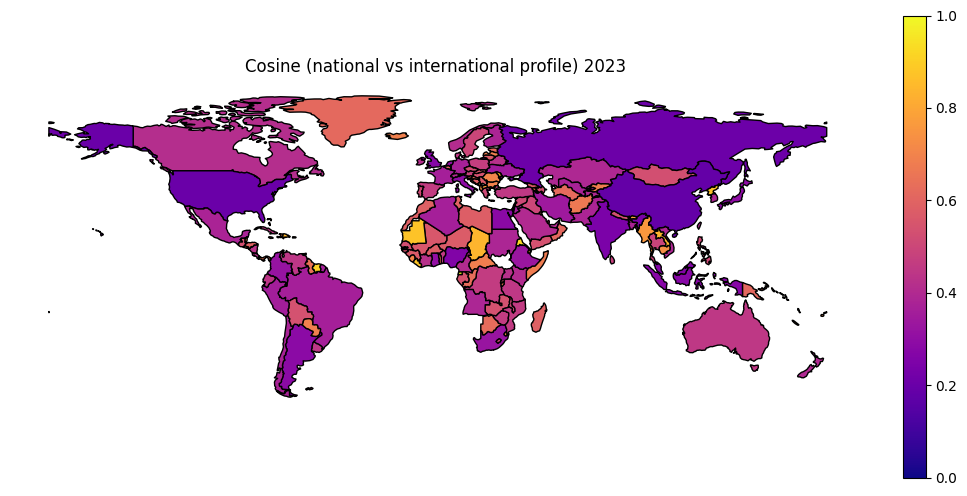

In [308]:
_, _ = uf.plot_map_continuous(df_stats, "cosine_0", title=f"Cosine (national vs international profile) {year}", range=(0, 1))

# Compare boxplots

In [31]:
metrics = ["jaccard", "jaccard_turn", "w1_tree"]

In [32]:
# df_stats

In [33]:
df_box = (df_stats.reset_index().melt(id_vars=["country", "alpha-3", "name", "region"], var_name="metric", value_vars=metrics, value_name="value"))

In [34]:
# df_box

In [43]:
px.box(
    df_box,
    x="metric",
    y="value",
    points="all",
    hover_data=["country", "name", "region"],
    title="Dissimilarity measurement comparison: 0 -- the same, 1 -- distant",
    color="metric"
)

In [36]:
# px.histogram(
#     df_stats,
#     x=metrics,
#     barmode="group",
# )

In [37]:
# metric = ["w1_tree", "jaccard"]
# px.bar(df_stats.sort_values(metric), x="alpha-3", y=metric, hover_data=["alpha-3", "name", "region"], barmode="group")

In [38]:
# px.scatter(
#     df_stats,
#     x="jaccard",
#     y="w1_tree",
#     color="region",
#     hover_data=["alpha-3", "name", "region"],
# )

In [39]:
# px.bar(df_stats.loc[uf.top_n_countries_by_articles(15)], x="name", y=metrics, barmode="group")

In [40]:
# country = "PL"
# df_profile_country = pd.concat([
#     df_prob_indiv.loc[country].to_frame("indiv"), df_prob_collab.loc[country].to_frame("collab")
# ])
# px.bar(df_profile_country, x=df_profile_country.index, y=["indiv", "collab"], barmode="overlay")

In [41]:
uf.get_subfield_info(3312)

,subfield_id,subfield_name,field_name,domain_name
54,3312,Sociology and Political Science,Social Sciences,Social Sciences


In [42]:
df_stats.loc["US"]

alpha-3                                  USA
name                United States of America
sub-region                  Northern America
region                              Americas
total_indiv                         642572.0
total_collab                        250562.0
log_total_indiv                    13.373234
log_total_collab                   12.431462
gini_indiv                          0.654047
gini_collab                         0.634068
jaccard                             0.003984
jaccard_turn                             0.0
w1_tree                             0.097569
Name: US, dtype: object

# Compare global

In [45]:
subfield_tree = uf.get_subfield_tree(uf.df_topics)

df_global = pd.read_csv(uf.PATH+"df_global_comparison_yearly.csv").query("year == @year")
df_global.subfield_id = df_global.subfield_id.astype(int)
df_global = (
    df_global
    .set_index("subfield_id")
    .assign(
        z_score_individual=lambda df: (df.counts_individual - df.counts_individual.mean()) / df.counts_individual.std(),
        z_score_collab=lambda df: (df.counts_collab - df.counts_collab.mean()) / df.counts_collab.std(),
    )
)

In [46]:
uf.get_dist_w1_tree(subfield_tree,
                    df_global.reset_index("subfield_id").assign(subfield_str=lambda df: df.subfield_id.astype(str)).set_index("subfield_str").probability_individual.dropna().to_dict(),
                    df_global.reset_index("subfield_id").assign(subfield_str=lambda df: df.subfield_id.astype(str)).set_index("subfield_str").probability_collab.dropna().to_dict())

(np.float64(0.9999999999999885),
 np.float64(0.9999999999999891),
 np.float64(0.2313409774457337))

In [47]:
# px.bar(df_global, x=df_global.index.astype(str), y=["probability_individual", "probability_collab"], barmode="overlay")

In [48]:
uf.get_subfield_info(2505)

,subfield_id,subfield_name,field_name,domain_name
73,2505,Materials Chemistry,Materials Science,Physical Sciences


In [49]:
sp.special.kl_div(df_global.probability_individual, df_global.probability_collab).sum()

np.float64(0.0921665547252884)

# Compare close to global

In [50]:
global_dict_indiv = (
    df_global
    .reset_index("subfield_id")
    .assign(subfield_str=lambda df: df.subfield_id.astype(str))
    .set_index("subfield_str")
    .probability_individual
    .dropna()
    .to_dict()
)
global_dict_collab = (
    df_global
    .reset_index("subfield_id")
    .assign(subfield_str=lambda df: df.subfield_id.astype(str))
    .set_index("subfield_str")
    .probability_collab
    .dropna()
    .to_dict()
)


In [51]:
# df_global

In [52]:
importlib.reload(uf)

<module 'irina.utility_functions' from '/Users/irinavorobeva/PycharmProjects/geoTopics/irina/utility_functions.py'>

In [53]:
# different subfield, fields, domains (maximum distance)
subfield1 = "2713"
subfield2 = "1904"
_, _, w1_max = uf.get_dist_w1_tree(subfield_tree, {subfield1: 1}, {subfield2: 1})

uf.get_jaccard(df_stats, df_cs_collab, df_global, col_name="jaccard_gl_collab", col_df2="counts_collab")
uf.get_jaccard(df_stats, df_cs_indiv, df_global, col_name="jaccard_gl_indiv", col_df2="counts_individual")

uf.get_w1_tree(df=df_stats, subfield_tree=subfield_tree, df1=df_prob_collab, dict2=global_dict_collab, col_name="w1_tree_gl_collab")
uf.get_w1_tree(df=df_stats, subfield_tree=subfield_tree, df1=df_prob_indiv, dict2=global_dict_indiv, col_name="w1_tree_gl_indiv", w1_max=w1_max)

In [54]:
# df_stats

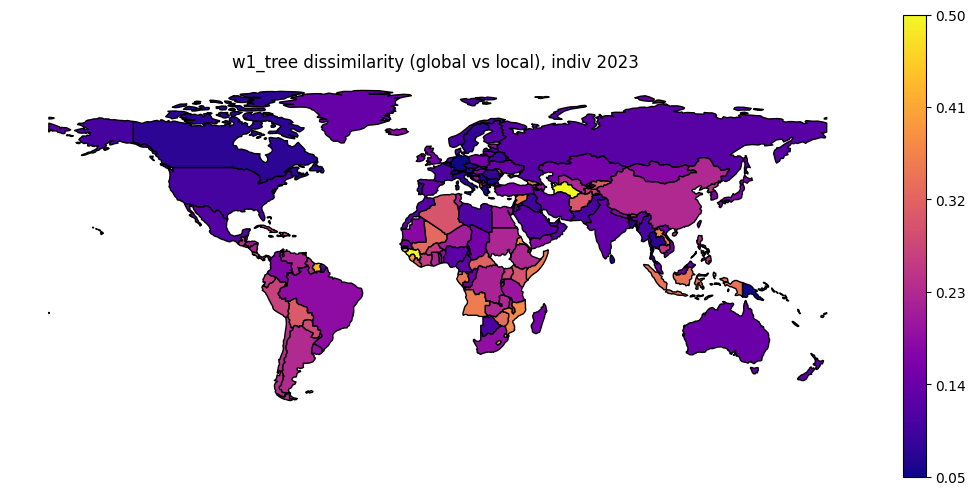

In [55]:
mode = "w1_tree"
regime = "indiv"
_, _ = uf.plot_map_continuous(df_stats, f"{mode}_gl_{regime}", title=f"{mode} dissimilarity (global vs local), {regime} {year}", range=(0.05, 0.5))

In [57]:
px.histogram(
    df_stats,
    x=["jaccard_gl_collab", "jaccard_gl_indiv"],
    histnorm="probability",
    nbins=50,
    barmode="group",
)

In [58]:
df_box_gl = (df_stats.reset_index().melt(id_vars=["country", "alpha-3", "name", "region"],
                                         var_name="metric",
                                         value_vars=["w1_tree_gl_indiv", "w1_tree_gl_collab", "jaccard_gl_collab", "jaccard_gl_indiv"], value_name="value"))

In [59]:
# px.box(
#     df_box_gl,
#     x="metric",
#     y="value",
#     points="all",
#     hover_data=["alpha-3", "name", "region"],
#     color="metric",
#     title="Dissimilarity comparison: local vs global"
# )

In [60]:
# px.scatter(
#     df_stats,
#     x="jaccard_gl_collab",
#     y="w1_tree_gl_collab",
#     hover_data=["alpha-3", "name", "region"],
#     color="region"
# )

In [61]:
# px.scatter(
#     df_stats,
#     x="jaccard_gl_indiv",
#     y="w1_tree_gl_indiv",
#     hover_data=["alpha-3", "name", "region"],
#     color="region"
# )

# Pipeline yearly



In [62]:
importlib.reload(uf)

<module 'irina.utility_functions' from '/Users/irinavorobeva/PycharmProjects/geoTopics/irina/utility_functions.py'>

In [63]:
start_year = 1970
end_year = 2023

subfield1 = "2713"
subfield2 = "1904"

subfield_tree = uf.get_subfield_tree(uf.df_topics)
_, _, w1_max = uf.get_dist_w1_tree(subfield_tree, {subfield1: 1}, {subfield2: 1})

df_stats_list = []
for year_loop in range(start_year, end_year+1):
    try:
        df_cs_indiv_loop = pd.read_csv(uf.PATH+"df_country_subfield/individual_{}.csv".format(year_loop), index_col=0)
        df_cs_collab_loop = pd.read_csv(uf.PATH+"df_country_subfield/collaborative_{}.csv".format(year_loop), index_col=0)

        all_cols = df_cs_indiv_loop.columns.union(df_cs_collab_loop.columns)

        df_cs_collab_loop = df_cs_collab_loop.reindex(columns=all_cols)
        df_cs_indiv_loop = df_cs_indiv_loop.reindex(columns=all_cols)

        df_global_loop = pd.read_csv(uf.PATH+"df_global_comparison_yearly.csv").drop_duplicates().query("year == @year_loop")
        df_global_loop.subfield_id = df_global_loop.subfield_id.astype(int)
        df_global_loop = (
            df_global_loop
            .set_index("subfield_id")
            .assign(
                z_score_individual=lambda df: (df.counts_individual - df.counts_individual.mean()) / df.counts_individual.std(),
                z_score_collab=lambda df: (df.counts_collab - df.counts_collab.mean()) / df.counts_collab.std(),
            )
        )

        global_dict_indiv_loop = (
        df_global_loop
        .reset_index("subfield_id")
        .assign(subfield_str=lambda df: df.subfield_id.astype(str))
        .set_index("subfield_str")
        .probability_individual
        .dropna()
        .to_dict()
        )
        global_dict_collab_loop = (
            df_global_loop
            .reset_index("subfield_id")
            .assign(subfield_str=lambda df: df.subfield_id.astype(str))
            .set_index("subfield_str")
            .probability_collab
            .dropna()
            .to_dict()
        )

        df_prob_collab_loop = df_cs_collab_loop.div(df_cs_collab_loop.sum(axis=1), axis=0)
        df_prob_indiv_loop = df_cs_indiv_loop.div(df_cs_indiv_loop.sum(axis=1), axis=0)

        df_stats_loop = (
            pd.DataFrame(index=(df_cs_indiv_loop.index.union(df_cs_collab_loop.index)))
            .merge(uf.df_country[["alpha-2", "alpha-3", "name", "region"]], left_index=True, right_on="alpha-2")
            .rename(columns={"alpha-2": "country"})
            .set_index("country")
            .assign(year=year_loop)
        )

        uf.get_jaccard(df_stats_loop, df_cs_collab_loop, df_cs_indiv_loop, col_name="jaccard")
        uf.get_jaccard(df_stats_loop, df_cs_collab_loop, df_global_loop, col_name="jaccard_gl_collab", col_df2="counts_collab")
        uf.get_jaccard(df_stats_loop, df_cs_indiv_loop, df_global_loop, col_name="jaccard_gl_indiv", col_df2="counts_individual")

        uf.get_w1_tree(df=df_stats_loop, subfield_tree=subfield_tree, df1=df_prob_collab_loop, df2=df_prob_indiv_loop, col_name="w1_tree", w1_max=w1_max)
        uf.get_w1_tree(df=df_stats_loop, subfield_tree=subfield_tree, df1=df_prob_collab_loop, dict2=global_dict_collab_loop, col_name="w1_tree_gl_collab", w1_max=w1_max)
        uf.get_w1_tree(df=df_stats_loop, subfield_tree=subfield_tree, df1=df_prob_indiv_loop, dict2=global_dict_indiv_loop, col_name="w1_tree_gl_indiv", w1_max=w1_max)

        df_stats_list.append(df_stats_loop)
    except Exception as e:
        print(year_loop, e)

KeyboardInterrupt: 

In [22]:
# pd.concat(df_stats_list).reset_index().to_csv(uf.PATH+"df_stats_national_international_1970_2023.csv", index=False)

In [23]:
df_stats_dyn = pd.concat(df_stats_list).reset_index()

In [ ]:
# start_year = 1970
# end_year = 2023
# year_list = range(start_year, end_year+1)
#
# mode_list = ["individual", "collaborative"]
#
# df_prob_yearly_list = []
#
#
# for year_loop in year_list:
#     for mode_loop in mode_list:
#         df_tmp = pd.read_csv(uf.PATH+f"df_country_subfield/{mode_loop}_{year_loop}.csv", index_col=0)
#         df_prob_yearly_list.append(
#             df_tmp.div(df_tmp.sum(axis=1), axis=0).reset_index().assign(year=year_loop, mode=mode_loop)
#         )
#
# df_prob_yearly = pd.concat(df_prob_yearly_list)

In [14]:
# df_prob_yearly.to_csv(uf.PATH+f"df_prob_yearly.csv", index=False)

# Plot yearly

In [7]:
df_stats_dyn = pd.read_csv(uf.PATH+"df_stats_national_international_1970_2023.csv")
df_prob_yearly = pd.read_csv(uf.PATH+"df_prob_yearly.csv")

In [65]:
# df_stats_dyn

In [185]:
test_year = 2010
fig = px.box(
    (
        df_stats_dyn
        # .query("year > @test_year")
    ),
    x="year",
    y="jaccard",
    points="outliers",
    hover_data=["country"],
    title="Jaccard dissimilarity between national and international profiles"
    # color="region"
)
fig.show()
# fig.write_image("../images/w1_tree_box_1970_2023.png",
#                 width=1200, height=600, scale=2)

In [186]:
test_year = 2010
fig = px.box(
    (
        df_stats_dyn
        # .query("year > @test_year")
    ),
    x="year",
    y="w1_tree",
    points="outliers",
    hover_data=["country"],
    title="W1-tree Distance between national and international profiles"
    # color="region"
)
fig.show()
# fig.write_image("../images/w1_tree_box_1970_2023.png",
#                 width=1200, height=600, scale=2)

In [232]:
year = 2023
px.scatter(
    df_stats_dyn.query("year == @year"),
    x="jaccard",
    y="w1_tree",
    hover_data=["country"],
    title=f"Distances {year}"
)

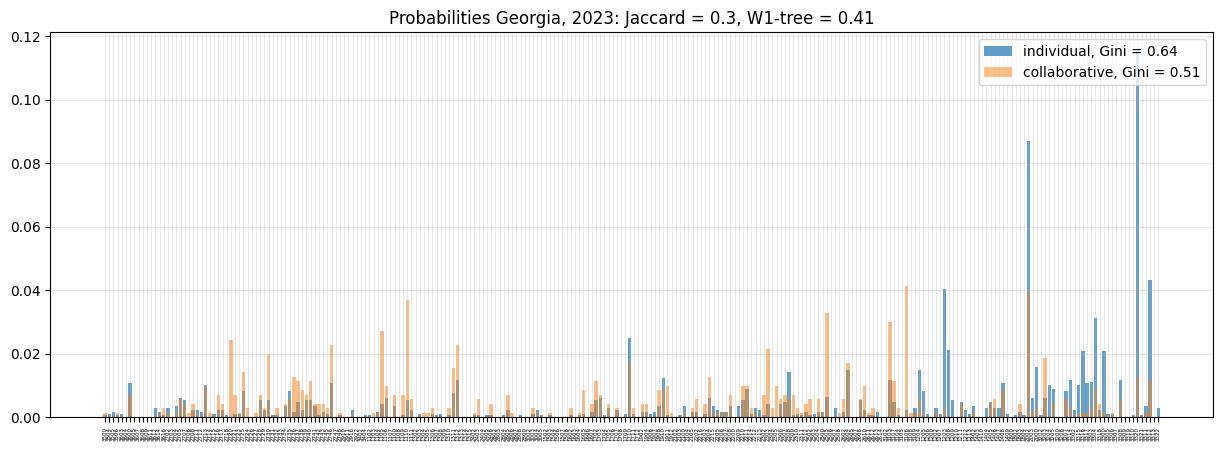

In [233]:
country = "CN" # small Jaccard, small W1
# country = "TN" # small Jaccard, relatively big W1
# country="MR" # big Jaccard, relatively big W1
# country = "ST" # relatively big Jaccard small W1
country="GE" # big W1
# country = "TV" # J=1, W1=1
# country = "AW" # big Jaccard (1), big W1
year = 2023

jaccard = df_stats_dyn.set_index(["country", "year"]).loc[(country, year), "jaccard"]
w1_tree = df_stats_dyn.set_index(["country", "year"]).loc[(country, year), "w1_tree"]

df_plot = (
    df_prob_yearly
    .query(f"country == @country and year == @year")
    .drop(["year", "country"], axis=1)
    .set_index("mode")
    .T
    .assign(subfield_id=lambda df: df.index.astype(int))
    .merge(uf.df_topics[["subfield_id", "subfield_name", "field_name", "domain_name"]].drop_duplicates(), on="subfield_id", how="left")
    .sort_values(["domain_name", "field_name", "subfield_name"])
    .assign(subfield_str=lambda df: df.subfield_id.astype(str))
    [["individual", "collaborative", "subfield_str"]]
    .set_index("subfield_str")
    .T
)

plt.subplots(figsize=[15, 5])
plt.bar(df_plot.columns,
        df_plot.loc[mode_list[0]], alpha=0.7, label=f"{mode_list[0]}, Gini = {round(uf.gini(df_plot.loc[mode_list[0]]), 2)}")
plt.bar(df_plot.columns,
        df_plot.loc[mode_list[1]], alpha=0.5, label=f"{mode_list[1]}, Gini = {round(uf.gini(df_plot.loc[mode_list[1]]), 2)}")
plt.xticks(rotation=90, fontsize=4)
plt.legend()
plt.title(f"Probabilities {uf.id2name_country[country]}, {year}: Jaccard = {round(jaccard, 2)}, W1-tree = {round(w1_tree, 2)}")
plt.grid(alpha=0.3)
plt.show()

In [229]:
year = 2022
country_list = ["US", "CN", "ES", "TN", "GE", "MR", "ST"]

jaccard = lambda country: round(df_stats_dyn.set_index(["country", "year"]).loc[(country, year), "jaccard"], 2)
w1 = lambda country : round(df_stats_dyn.set_index(["country", "year"]).loc[(country, year), "w1_tree"], 2)

legend_name = lambda country: f"J={jaccard(country)}, W1={w1(country)} -- {uf.id2name_country[country]}"

df_box = (
    df_prob_yearly.query(f"year == @year and country in @country_list and mode == \"{mode_list[0]}\"").drop(["year", "mode"], axis=1).set_index("country")
    .sub(df_prob_yearly.query(f"year == @year and country in @country_list and mode == \"{mode_list[1]}\"").drop(["year", "mode"], axis=1).set_index("country"))
    .reset_index(names="country")
    .melt(id_vars=["country"], var_name="subfield_id", value_name="value")
)
fig = px.box(
    df_box,
    x="value",
    y="country",
    points="outliers",
    title="Distributions: Prob(individual) - Prob(collaborative)",
    color="country"
)
fig.for_each_trace(
    lambda t: t.update(
        name=legend_name(t.name),
    )
)

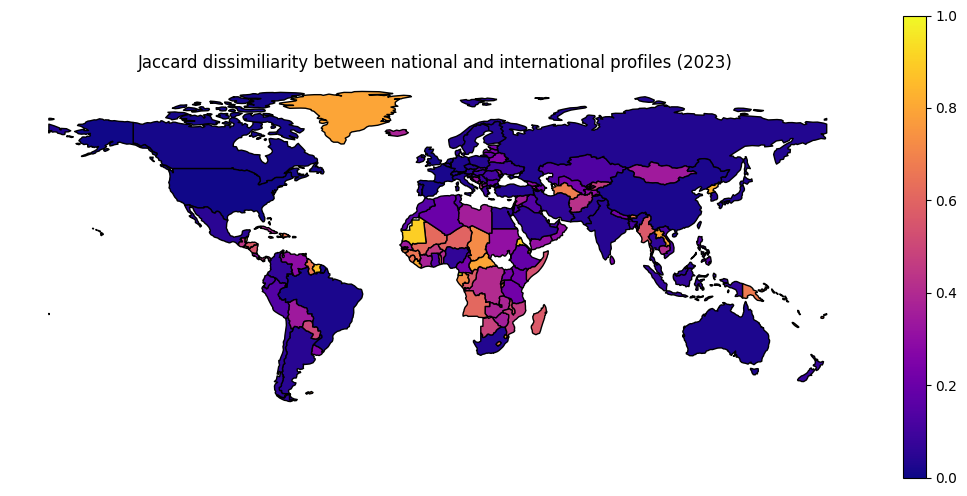

In [217]:
year = 2023
fig, ax = uf.plot_map_continuous((
    df_stats_dyn
    .query("year == @year")
), "jaccard", range = (0, 1), title=f"Jaccard dissimiliarity between national and international profiles ({year})"
)
# fig.savefig(f"../images/map_w1_tree_{year}.png")

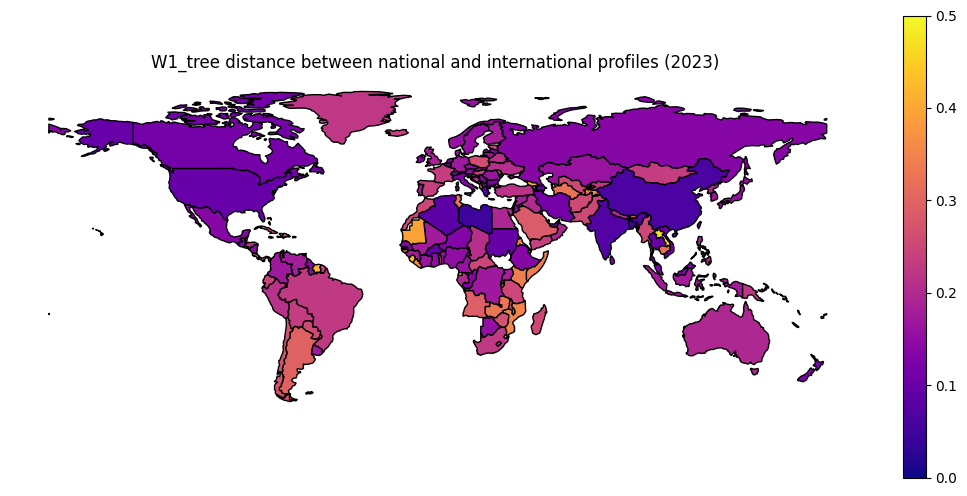

In [216]:
year = 2023
fig, ax = uf.plot_map_continuous((
    df_stats_dyn
    .query("year == @year")
), "w1_tree", range = (0, 0.5), title=f"W1_tree distance between national and international profiles ({year})"
)
# fig.savefig(f"../images/map_w1_tree_{year}.png")

In [68]:
# df_cs_indiv = pd.read_csv(uf.PATH+"df_country_subfield/individual_{}.csv".format(year), index_col=0)
# df_cs_collab = pd.read_csv(uf.PATH+"df_country_subfield/collaborative_{}.csv".format(year), index_col=0)
#
# df_prob_collab = df_cs_collab.div(df_cs_collab.sum(axis=1), axis=0)
# df_prob_indiv = df_cs_indiv.div(df_cs_indiv.sum(axis=1), axis=0)

In [69]:
# country = "BM"
# df_profile_country = pd.concat([
#     df_prob_indiv.loc[country].to_frame("indiv"), df_prob_collab.loc[country].to_frame("collab")
# ])
# px.bar(df_profile_country, x=df_profile_country.index, y=["indiv", "collab"], barmode="overlay")